###### Reading one file

In [1]:
import pandas as pd

df = pd.read_csv("LA_Retail_Sales.csv")

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          750 non-null    str    
 1   store_name        750 non-null    str    
 2   product_category  750 non-null    str    
 3   date              750 non-null    str    
 4   Unit sales        745 non-null    float64
 5   DOLLAR SALES      743 non-null    float64
 6   store_zip         750 non-null    str    
 7   promotion_flag    750 non-null    bool   
dtypes: bool(1), float64(2), str(5)
memory usage: 41.9 KB


###### Reading mutlpile files from a folder

In [7]:
import glob

file_paths = glob.glob("LA_Retail_Sales_By_Day/*.csv")

df = pd.concat([pd.read_csv(fp) for fp in file_paths], ignore_index=True)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   store_id          750 non-null    str    
 1   store_name        750 non-null    str    
 2   product_category  750 non-null    str    
 3   date              750 non-null    str    
 4   unit_sales        745 non-null    float64
 5   dollar_sales      743 non-null    float64
 6   store_zip         750 non-null    str    
 7   promotion_flag    750 non-null    bool   
dtypes: bool(1), float64(2), str(5)
memory usage: 41.9 KB


###### Reading specific files from the folder containing many files

In [14]:
sales_df = pd.DataFrame()

for day in range(1,6):
    day_df = pd.read_csv(f"LA_Retail_Sales_By_Day/sales_2024-09-{day:02d}.csv")
    sales_df = pd.concat([sales_df,day_df])

In [15]:
print(sales_df)

   store_id store_name product_category        date  unit_sales  dollar_sales  \
0     LA002    Store_2        Household  2024-09-01        16.0         96.28   
1     LA001    Store_1        Beverages  2024-09-01        14.0         86.63   
2     LA008    Store_8          Produce  2024-09-01         4.0         79.99   
3     LA010   Store_10        Beverages  2024-09-01        22.0        140.45   
4     LA006    Store_6           Snacks  2024-09-01        17.0         50.03   
..      ...        ...              ...         ...         ...           ...   
18    LA002    Store_2        Household  2024-09-05         2.0         16.21   
19    LA010   Store_10        Beverages  2024-09-05        45.0        469.30   
20    LA002    Store_2           Snacks  2024-09-05        20.0        210.86   
21    LA005    Store_5           Snacks  2024-09-05         9.0        176.94   
22    LA002    Store_2        Household  2024-09-05        38.0        313.92   

   store_zip  promotion_fla

###### Extract from Json

In [21]:
df = pd.read_json("LA_Retail_Sales.json", lines=True)
df.head()

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag
0,LA002,Store_2,Household,2024-09-01,16.0,96.28,90004,True
1,LA001,Store_1,Beverages,2024-09-01,14.0,86.63,90004,True
2,LA004,Store_4,Produce,2024-09-15,18.0,298.26,90003,True
3,LA003,Store_3,Household,2024-09-07,7.0,25.69,90001,True
4,LA008,Store_8,Beverages,2024-09-18,25.0,85.46,90005,False


###### Extract from Parquet

In [3]:
df = pd.read_parquet("LA_Retail_Sales.parquet")
df.head()

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag
0,LA002,Store_2,Household,2024-09-01,16.0,96.28,90004,True
1,LA001,Store_1,Beverages,2024-09-01,14.0,86.63,90004,True
2,LA004,Store_4,Produce,2024-09-15,18.0,298.26,90003,True
3,LA003,Store_3,Household,2024-09-07,7.0,25.69,90001,True
4,LA008,Store_8,Beverages,2024-09-18,25.0,85.46,90005,False


###### Extract from SQL

In [6]:
import sqlite3

conn = sqlite3.connect("la_sales.sqlite")

In [8]:
df = pd.read_sql("SELECT * FROM Sales", con=conn)
df.head()

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag,rev_per_unit,temp
0,LA002,Store_2,Household,2024-09-01 00:00:00,16,96.28,90004,1,6.02,71.19
1,LA001,Store_1,Beverages,2024-09-01 00:00:00,14,86.63,90004,1,6.19,71.19
2,LA004,Store_4,Produce,2024-09-15 00:00:00,18,298.26,90003,1,16.57,63.91
3,LA003,Store_3,Household,2024-09-07 00:00:00,7,25.69,90001,1,3.67,78.37
4,LA008,Store_8,Beverages,2024-09-18 00:00:00,25,85.46,90005,0,3.42,60.82


###### Sorting using different queries

In [9]:
pd.read_sql('''
    SELECT store_id, sum(dollar_sales) as total_sales
    FROM Sales    
    GROUP BY store_id
    ORDER BY total_sales DESC
''', con=conn)

,store_id,total_sales
0,LA010,26671.40
1,LA006,23636.70
2,LA009,22089.83
3,LA001,20941.15
4,LA008,20765.75
5,LA003,20731.63
6,LA002,20130.76
7,LA005,19757.50
8,LA004,16749.46
9,LA007,15554.02


###### Data Visualization

<Axes: xlabel='store_id'>

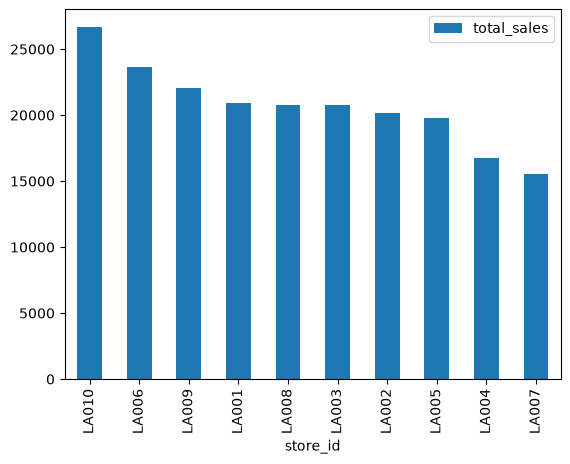

In [12]:
pd.read_sql('''
    SELECT store_id, sum(dollar_sales) as total_sales
    FROM Sales    
    GROUP BY store_id
    ORDER BY total_sales DESC
''', con=conn).set_index("store_id").plot.bar()

###### Extract from an API

In [ ]:
import requests
import time
from datetime import datetime

In [16]:
API_KEY = "5883b9ac08253fbd080c073b1832a6a8"
LAT, LON = 34.0522, -118.2437 #Cordinates for Los Angeles

In [20]:
df["date"]

0      2024-09-01 00:00:00
1      2024-09-01 00:00:00
2      2024-09-15 00:00:00
3      2024-09-07 00:00:00
4      2024-09-18 00:00:00
              ...         
733    2024-09-24 00:00:00
734    2024-09-14 00:00:00
735    2024-09-14 00:00:00
736    2024-09-28 00:00:00
737    2024-09-24 00:00:00
Name: date, Length: 738, dtype: str

###### TRANSFORM from Pandas

In [21]:
df = pd.read_csv("LA_Retail_Sales.csv")

df.columns

Index(['store_id', 'store_name', 'product_category', 'date', 'Unit sales',
       'DOLLAR SALES', 'store_zip', 'promotion_flag'],
      dtype='str')

In [23]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.columns

Index(['store_id', 'store_name', 'product_category', 'date', 'unit_sales',
       'dollar_sales', 'store_zip', 'promotion_flag'],
      dtype='str')

###### Checking revenue earned per unit

In [26]:
df["rev_per_unit"] = (df["dollar_sales"] / df["unit_sales"]).round(2)
df.head()

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag,rev_per_unit
0,LA002,Store_2,Household,9/1/24,16.0,96.28,90004,True,6.02
1,LA001,Store_1,Beverages,9/1/24,14.0,86.63,90004,True,6.19
2,LA004,Store_4,Produce,9/15/24,18.0,298.26,90003,True,16.57
3,LA003,Store_3,Household,9/7/24,7.0,25.69,90001,True,3.67
4,LA008,Store_8,Beverages,9/18/24,25.0,85.46,90005,False,3.42


In [30]:
df.store_zip.value_counts()

store_zip
90003    138
90004    136
90001    126
90005    122
900XX    119
90002    109
Name: count, dtype: int64

In [32]:
df["store_zip"] = df["store_zip"].str.replace('XX', '00')

In [33]:
df.store_zip.value_counts()

store_zip
90003    138
90004    136
90001    126
90005    122
90000    119
90002    109
Name: count, dtype: int64

###### LOAD DATA

In [34]:
df.to_sql("Sales", if_exists="replace", index=False, con=conn)

750

In [35]:
pd.read_sql("SELECT * FROM Sales", con=conn)

,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag,rev_per_unit
0,LA002,Store_2,Household,9/1/24,16.0,96.28,90004,1,6.02
1,LA001,Store_1,Beverages,9/1/24,14.0,86.63,90004,1,6.19
2,LA004,Store_4,Produce,9/15/24,18.0,298.26,90003,1,16.57
3,LA003,Store_3,Household,9/7/24,7.0,25.69,90001,1,3.67
4,LA008,Store_8,Beverages,9/18/24,25.0,85.46,90005,0,3.42
...,...,...,...,...,...,...,...,...,...
745,LA010,Store_10,Beverages,9/24/24,46.0,790.99,90005,1,17.20
746,LA008,Store_8,Snacks,9/14/24,23.0,375.40,90003,0,16.32
747,LA004,Store_4,Personal Care,9/14/24,17.0,225.24,90000,0,13.25
748,LA009,Store_9,Snacks,9/28/24,37.0,406.47,90004,0,10.99
